In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np

# Loading Dataset
file_path_2024 = '/content/drive/MyDrive/Data Science Projects/Cognitive Banking Assistant/CFPB_Consumer_Complaints_2024.csv'
data_cfpb = pd.read_csv(file_path_2024, sep=',')
data_cfpb.head()

,date_received,product,subproduct,issue,subissue,consumer_complaint_narrative,company_public_response,company_name,state,zip_code,tags,consumer_consent_provided,submitted_via,date_sent_to_company,company_response_to_consumer,timely_response,consumer_disputed,complaint_id
0,10/16/2020,"Credit reporting, credit repair services, or o...",Credit repair services,Fraud or scam,NaN,NaN,NaN,ERC,NaN,NaN,NaN,NaN,Phone,10/19/2020,Closed with explanation,True,NaN,3903929
1,10/24/2014,Credit reporting,NaN,Incorrect information on credit report,Account terms,NaN,NaN,ERC,LA,70816.0,"Older American, Servicemember",NaN,Web,10/29/2014,Closed with non-monetary relief,True,False,1085252
2,3/14/2015,Credit reporting,NaN,Incorrect information on credit report,Account terms,NaN,NaN,ERC,AL,35242.0,NaN,NaN,Web,3/20/2015,Closed with non-monetary relief,True,False,1283279
3,7/13/2015,Debt collection,"Other (i.e. phone, health club, etc.)",Cont'd attempts collect debt not owed,Debt was paid,"During my time as an employee for XXXX, I was ...",Company believes it acted appropriately as aut...,ERC,CO,80916.0,NaN,Consent provided,Web,7/13/2015,Closed with non-monetary relief,True,False,1465916
4,9/21/2018,Debt collection,Other debt,Attempts to collect debt not owed,Debt was paid,NaN,Company believes it acted appropriately as aut...,ERC,KY,41008.0,NaN,Consent not provided,Web,9/21/2018,Closed with explanation,True,NaN,3025580


# **Step 1: Financial Text Processing & OOP Architecture**

In [3]:
import pandas as pd
import numpy as np
import re

class BankingTextProcessor:
  def __init__(self, raw_df):
    self.raw_df = raw_df.copy()
    self.clean_df = None

  # 1) Text Normalization
  def _normalize_financial_text(self, text):
    """Helper Method: The Mathematical Preparation"""
    if pd.isna(text):
      return ""

    text = str(text).lower()
    text = re.sub(r'x{2,}', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

  def build_semantic_knowledge_base(self):
    """Noise Filtering & Feature Engineering"""
    print(f"Initial raw tickets: {len(self.raw_df)}")

    # 2) Noise Filtering
    df = self.raw_df.dropna(subset=['consumer_complaint_narrative']).copy()
    print(f"Tickets containing text: {len(df)}")

    df['subproduct'] = df['subproduct'].fillna('Unknown')
    df['issue'] = df['issue'].fillna('General Issue')

    print("Harmonizing messy category labes...")
    label_mapping = {
      "Credit reporting, credit repair services, or other personal consumer reports": "Credit Reporting",
      "Credit reporting": "Credit Reporting",
      "Debt collection": "Debt Collection"
    }

    df['product'] = df['product'].replace(label_mapping)

    print("Applying Deep Text Normalisation... (This may take moment)")
    df['clean_narrative'] = df['consumer_complaint_narrative'].apply(self._normalize_financial_text)

    # 3) Feature Engineering
    df['semantic_context'] = (
        "Product: " + df['product'] + " | " +
        "Issue: " + df['issue'] + " | " +
        "Customer Statement: " + df['clean_narrative']
    )

    self.clean_df = df[['complaint_id', 'product', 'issue', 'clean_narrative', 'semantic_context', 'company_response_to_consumer']]
    self.clean_df = self.clean_df.reset_index(drop=True)
    print("Pipeline Completed! Financial Knowledge Base is ready.")
    return self.clean_df

# 4) Execution
processor = BankingTextProcessor(data_cfpb)
knowledge_base_df = processor.build_semantic_knowledge_base()
knowledge_base_df.head()

Initial raw tickets: 500
Tickets containing text: 200
Harmonizing messy category labes...
Applying Deep Text Normalisation... (This may take moment)
Pipeline Completed! Financial Knowledge Base is ready.


,complaint_id,product,issue,clean_narrative,semantic_context,company_response_to_consumer
0,1465916,Debt Collection,Cont'd attempts collect debt not owed,during my time as an employee for i was encour...,Product: Debt Collection | Issue: Cont'd attem...,Closed with non-monetary relief
1,1903865,Debt Collection,Cont'd attempts collect debt not owed,i have been monitoring my credit weekly for ye...,Product: Debt Collection | Issue: Cont'd attem...,Closed with non-monetary relief
2,3174523,Debt Collection,Attempts to collect debt not owed,i previously had phone service with my bill wa...,Product: Debt Collection | Issue: Attempts to ...,Closed with explanation
3,4372086,Debt Collection,Attempts to collect debt not owed,several debt collectors have called me on beha...,Product: Debt Collection | Issue: Attempts to ...,Closed with explanation
4,3737269,Debt Collection,Attempts to collect debt not owed,on i settled and paid a debt with enhance reco...,Product: Debt Collection | Issue: Attempts to ...,Closed with explanation


# **Step 2: Traditional NLP for Ticket Routing (TF-IDF & Cosine Similarity)**

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import numpy as np

class SimilarityEngine:
  def __init__(self, knowledge_base_df):
    self.kb_df = knowledge_base_df.copy()

    self.vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
    self.tfidf_matrix = None

  # 1) Mapping Tickets to Vectors
  def map_text_to_vectors(self):
    """Converting Historical Dataset into Mathematical Matrix."""
    print("Mapping historical tickets to mathematical vectors (TF-IDF)...")
    self.tfidf_matrix = self.vectorizer.fit_transform(self.kb_df['clean_narrative'])

    print(f"Matrix created! Shape: {self.tfidf_matrix.shape}")
    print("(Rows = Number of Tickets, Columns = Number of Words/Dimensions)")

  # 2) Finding Similarity Between Tickets
  def route_new_ticket(self, new_complaint_text, top_n=3):
    """"Finding the most mathematically similar past tickets to a new incoming one."""
    if self.tfidf_matrix is None:
      raise ValueError("You must run map_text_to_vectors() first!")

    print(f"\n--- Incoming Ticket: '{new_complaint_text}' ---")

    new_vector = self.vectorizer.transform([new_complaint_text])
    similarity_scores = cosine_similarity(new_vector, self.tfidf_matrix)
    flat_scores = similarity_scores.flatten()
    top_indices = flat_scores.argsort()[-top_n:][::-1]

    results = []
    for idx in top_indices:
      score = flat_scores[idx]
      ticket = self.kb_df.iloc[idx]
      results.append({
          'Similarity Score': f"{round(score * 100, 2)}",
          'Product': ticket['product'],
          'Historical Context': ticket['semantic_context']
      })

    return pd.DataFrame(results)

# Execution & Testing
engine = SimilarityEngine(knowledge_base_df)
engine.map_text_to_vectors()
new_email = "Someone stole my wallet and my credit card has fake fraud charges. I want a refund."
matched_tickets = engine.route_new_ticket(new_email, top_n=3)
display(matched_tickets)

Mapping historical tickets to mathematical vectors (TF-IDF)...
Matrix created! Shape: (200, 2023)
(Rows = Number of Tickets, Columns = Number of Words/Dimensions)

--- Incoming Ticket: 'Someone stole my wallet and my credit card has fake fraud charges. I want a refund.' ---


,Similarity Score,Product,Historical Context
0,27.53,Credit Reporting,Product: Credit Reporting | Issue: Incorrect i...
1,11.83,Debt Collection,Product: Debt Collection | Issue: False statem...
2,10.54,Debt Collection,Product: Debt Collection | Issue: False statem...


# **Step 3: Dense Financial Embeddings**

In [5]:
!pip install sentence-transformers

In [6]:
from sentence_transformers import SentenceTransformer, util
import pandas as pd
import numpy as np
import torch

class NeuralSemanticEngine:
  def __init__(self, knowledge_base_df):
    self.kb_df = knowledge_base_df.copy()

    # 1) Loading the Brain
    print("Downloading & Loading BGE Asymmetric Deep Learning Model...")
    self.model = SentenceTransformer('BAAI/bge-small-en-v1.5')
    self.dense_matrix = None

  # 2) Neural Compression
  def map_text_to_dense_vectors(self):
    """Passing all historical tickets through the neural network."""
    print("Encoding text into dense semantic vectors... (may take a minute)")

    self.dense_matrix = self.model.encode(self.kb_df['clean_narrative'].tolist(), convert_to_tensor=True)
    print(f"Neural Matrix Created! Shape: {self.dense_matrix.shape}")
    print("(Rows = Tickets, Columns = 384 Deep Learning Dimensions)")

  # 3) Finding Similarity Between Tickets
  def route_new_ticket_neural(self, new_complaint_text, top_n=3):
    """Finding semantic matches using Neural Embeddings."""
    if self.dense_matrix is None:
      raise ValueError("You must run map_text_to_dense_vectors() first!")

    print(f"\n--- Incoming Ticket (Neural): '{new_complaint_text}' ---")

    instruction_prompt = "Represent this sentence for searching relevant passages: "
    formatted_query = instruction_prompt + new_complaint_text

    new_vector = self.model.encode(formatted_query, convert_to_tensor=True)
    similarity_scores = util.cos_sim(new_vector, self.dense_matrix)[0]
    top_results = np.argpartition(-similarity_scores.cpu().numpy(), range(top_n))[:top_n]

    results = []
    for idx in top_results:
      score = similarity_scores[idx].item()
      ticket = self.kb_df.iloc[idx]
      results.append({
          'Neural Similarity Score': f"{round(score * 100, 2)}%",
          'Product': ticket['product'],
          'Historical Context': ticket['semantic_context']
      })

    return pd.DataFrame(results).sort_values(by='Neural Similarity Score', ascending=False).reset_index(drop=True)

# Execution & Testing
neural_engine = NeuralSemanticEngine(knowledge_base_df)
neural_engine.map_text_to_dense_vectors()
new_email = "Someone stole my wallet and my credit card has fake fraud charges. I want a refund."

neural_matched_tickets = neural_engine.route_new_ticket_neural(new_email, top_n=3)
display(neural_matched_tickets)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding text into dense semantic vectors... (may take a minute)
Neural Matrix Created! Shape: torch.Size([200, 384])
(Rows = Tickets, Columns = 384 Deep Learning Dimensions)

--- Incoming Ticket (Neural): 'Someone stole my wallet and my credit card has fake fraud charges. I want a refund.' ---


,Neural Similarity Score,Product,Historical Context
0,74.8%,Debt Collection,Product: Debt Collection | Issue: Attempts to ...
1,72.89%,Debt Collection,Product: Debt Collection | Issue: Attempts to ...
2,72.8%,Debt Collection,Product: Debt Collection | Issue: Cont'd attem...


# **Step 4: Vector Databases & Approximate Nearest Neighbours (ANN)**

In [7]:
#!pip install chromadb==0.4.24 "numpy<2"

In [8]:
import chromadb
import pandas as pd

class VectorDBRetriever:
  def __init__(self, knowledge_base_df, embedding_model):
    self.kb_df = knowledge_base_df.copy()
    self.model = embedding_model

    # 1) Initializing Vector Database Engine and Creating a "Collection"
    print("Initializing Vector Database (ChromaDB)...")
    self.chroma_client = chromadb.Client()

    try:
      self.chroma_client.delete_collection(name="banking_tickets_db")
      print("Found old database in memory.Cleared it for a fresh run.")
    except Exception:
      pass

    self.collection = self.chroma_client.create_collection(
        name="banking_tickets_db",
        metadata={"hnsw:space": "cosine"}
    )

  def populate_database(self):
    """Generating embeddings and building the HNSW graph inside the Data"""
    print("Populating Vector DB with historical tickets... (Building the HNSW Graph)")

    documents = self.kb_df['clean_narrative'].tolist()

    # 2) MetaData Storage
    metadatas = [{'product': row['product'], 'context': row['semantic_context']}
                for _, row in self.kb_df.iterrows()]
    ids = [str(idx) for idx in self.kb_df.index.tolist()]
    embeddings = self.model.encode(documents).tolist()
    self.collection.add(
        embeddings=embeddings,
        documents=documents,
        metadatas=metadatas,
        ids=ids
    )
    print(f"Successfully loaded {self.collection.count()} tickets into the Vector Database!")

  def retrieve_tickets(self, new_complaint_text, top_n=3):
    """Instantly searches the HNSW graph for the closest semantic neighbors."""

    print(f"\n--- Incoming Ticket (Vector DB): '{new_complaint_text}' ---")

    instruction_prompt = "Represent this sentence for searching relevant passages: "
    formatted_query = instruction_prompt + new_complaint_text

    query_embedding = self.model.encode([formatted_query]).tolist()

    results = self.collection.query(
        query_embeddings=query_embedding,
        n_results=top_n
    )

    # 3) Formatting the Output
    formatted_results = []
    for i in range(top_n):
      distance = results['distances'][0][i]
      similarity = 1 - distance

      formatted_results.append({
          'Vector DB Similarity': f"{round(similarity * 100, 2)}%",
          'Product': results['metadatas'][0][i]['product'],
          'Historical Context': results['metadatas'][0][i]['context']
      })

    return pd.DataFrame(formatted_results)

# Execution & Testing
db_retriever = VectorDBRetriever(knowledge_base_df, neural_engine.model)
db_retriever.populate_database()
new_email = "Someone stole my wallet and my credit card has fake fraud charges. I want a refund."

db_matched_tickets = db_retriever.retrieve_tickets(new_email, top_n=3)
display(db_matched_tickets)

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Initializing Vector Database (ChromaDB)...
Populating Vector DB with historical tickets... (Building the HNSW Graph)


ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionAddEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given


Successfully loaded 200 tickets into the Vector Database!

--- Incoming Ticket (Vector DB): 'Someone stole my wallet and my credit card has fake fraud charges. I want a refund.' ---


,Vector DB Similarity,Product,Historical Context
0,74.8%,Debt Collection,Product: Debt Collection | Issue: Attempts to ...
1,72.89%,Debt Collection,Product: Debt Collection | Issue: Attempts to ...
2,72.77%,Debt Collection,Product: Debt Collection | Issue: Attempts to ...


Executing Custom 6D Radar Projection


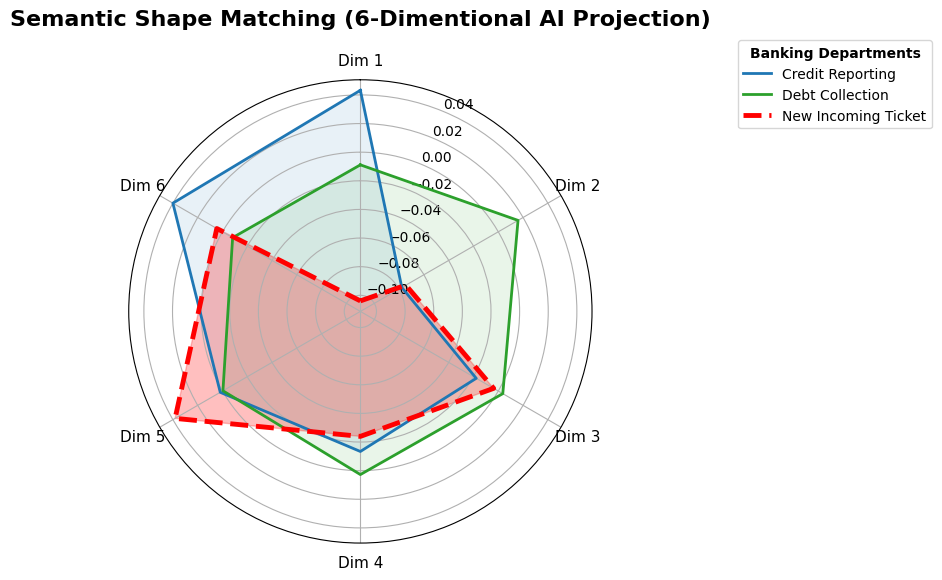

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import pandas as pd

def visualize_radar_chart(db_retriever, new_query_text):
  print("Executing Custom 6D Radar Projection")

  historical_texts = db_retriever.kb_df['clean_narrative'].tolist()
  historical_categories = db_retriever.kb_df['product'].tolist()

  historical_embeddings = db_retriever.model.encode(historical_texts, convert_to_tensor=True).cpu().numpy()
  instruction_prompt = "Represent this sentence for searching relevant passages: "
  query_embedding = db_retriever.model.encode([instruction_prompt + new_query_text], convert_to_tensor=True).cpu().numpy()

  pca = PCA(n_components=6)

  reduced_historical = pca.fit_transform(historical_embeddings)
  reduced_query = pca.transform(query_embedding)

  df_viz = pd.DataFrame(reduced_historical, columns=['Dim 1', 'Dim 2', 'Dim 3', 'Dim 4', 'Dim 5', 'Dim 6'])
  df_viz['Category'] = historical_categories
  centroids = df_viz.groupby('Category').mean()

  # Radar Chart Setup
  categories = centroids.index.tolist()
  labels = np.array(['Dim 1', 'Dim 2', 'Dim 3', 'Dim 4', 'Dim 5', 'Dim 6'])
  num_vars = len(labels)

  #Computing Angles for the Circle
  angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
  angles +=angles[:1]

  fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

  colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#9467bd', '#8c564b']
  for i, category in enumerate(categories):
    values = centroids.loc[category].values.flatten().tolist()
    values +=  values[:1]

    ax.plot(angles, values, color=colors[i % len(colors)], linewidth=2, label=category)
    ax.fill(angles, values, color=colors[i % len(colors)], alpha=0.1)

  query_values = reduced_query.flatten().tolist()
  query_values += query_values[:1]

  ax.plot(angles, query_values, color='red', linewidth=3.5, linestyle='dashed', label='New Incoming Ticket')
  ax.fill(angles, query_values, color='red', alpha=0.25)

  ax.set_theta_offset(np.pi / 2)
  ax.set_theta_direction(-1)
  ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=11)

  plt.title("Semantic Shape Matching (6-Dimentional AI Projection)", size=16, fontweight='bold', y=1.1)
  plt.legend(loc='upper left', bbox_to_anchor=(1.3, 1.1), title="Banking Departments", title_fontproperties={'weight':'bold'})
  plt.tight_layout()
  plt.show()

# Execution
new_email = "Someone stole my wallet and my credit card has fake fraud charges. I want a refund."
visualize_radar_chart(db_retriever, new_email)

# **Step 5: Generative AI (LLM Integration)**

In [10]:
!pip install -q -U google-genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.3/52.3 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 733.5/733.5 kB 14.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.26.0 requires opentelemetry-api<1.39.0,>=1.36.0, but you have opentelemetry-api 1.40.0 which is incompatible.
google-adk 1.26.0 requires opentelemetry-sdk<1.39.0,>=1.36.0, but you have opentelemetry-sdk 1.40.0 which is incompatible.


In [ ]:
from google import genai

API_KEY = ""
client = genai.Client(api_key=API_KEY)

print("Querying Google's Servers for available Generative Models...\n")

for model in client.models.list():
  print(f"Exact Model String: '{model.name}'")

Querying Google's Servers for available Generative Models...

Exact Model String: 'models/gemini-2.5-flash'
Exact Model String: 'models/gemini-2.5-pro'
Exact Model String: 'models/gemini-2.0-flash'
Exact Model String: 'models/gemini-2.0-flash-001'
Exact Model String: 'models/gemini-2.0-flash-lite-001'
Exact Model String: 'models/gemini-2.0-flash-lite'
Exact Model String: 'models/gemini-2.5-flash-preview-tts'
Exact Model String: 'models/gemini-2.5-pro-preview-tts'
Exact Model String: 'models/gemma-3-1b-it'
Exact Model String: 'models/gemma-3-4b-it'
Exact Model String: 'models/gemma-3-12b-it'
Exact Model String: 'models/gemma-3-27b-it'
Exact Model String: 'models/gemma-3n-e4b-it'
Exact Model String: 'models/gemma-3n-e2b-it'
Exact Model String: 'models/gemini-flash-latest'
Exact Model String: 'models/gemini-flash-lite-latest'
Exact Model String: 'models/gemini-pro-latest'
Exact Model String: 'models/gemini-2.5-flash-lite'
Exact Model String: 'models/gemini-2.5-flash-image'
Exact Model Str

In [22]:
from google import genai

class UniversalCognitiveAgent:
  def __init__(self, api_key):
    print("Initializing Universal Multilingual LLM Engine (Gemini 2.5 Flash)...")
    self.client = genai.Client(api_key=api_key)
    self.model_name = 'gemini-2.5-flash'

  def translate_query(self, foreign_email):
    print("Agent 1: Detecting language and translating to English for Database Search...")
    prompt = f"Translate the following customer complaint into clear English. ONLY output the English translation, nothing else.\n\nComplaint: {foreign_email}"

    response = self.client.models.generate_content(
        model=self.model_name,
        contents=prompt
    )
    return response.text.strip()

  def generate_resolution_email(self, original_email, retrieved_tickets_df):
    print("Agent 2: Drafting custom empathetic response in the customer's native language...")

    # 1) Compiling the English Historical Context
    history_string = ""
    for index, row in retrieved_tickets_df.iterrows():
      history_string += f"- Past Precedent {index + 1}: {row['Historical Context']}\n"

    # 2) Prompt Engineering
    system_prompt = f"""
    You are a friendly, deeply empathetic human customer support agent.
    A customer just emailed us this message:
    "{original_email}"
    CRITICAL RULE 1 (LANGUAGE UNIVERSALITY):
    You must detect the language the customer used in their message and write your ENTIRE reply in that same language. (e.g., if they wrote in Azerbaijani, reply in Azerbaijani. If Russian, reply in Russian. If Turkish, reply in Turkish, etc.).
    CRITICAL RULE 2 (RESOLUTION):
    Do not invent policies. Base your resolution strictly on how we solved similar issues in the past, provided in the English historical tickets below. Seamlessly translate these concepts into the customer's language.
    English Historical Tickets:
    {history_string}
    CRITICAL RULE 3 (TONE & INTRODUCTIONS):
    - NEVER start by summarizing the customer's problem back to them (e.g., do not say "I understand you are writing about your stollen wallet").
    - Start directly with a warm, natural human greeting and immediate empathy.
    - Example of a good start: "Salam. Başınıza gələn hadisəyə görə çox təəssüf edirəm, bu həqiqətən də çox stresli bir vəziyyətdir."
    - Keep sentences kind, conversational, short, easy to read, and avoid stiff corporate jargon. Try to understand what does the customer feel right now.
    - Output ONLY plain text. DO NOT generate any HTML tags, markdown, or formatting symbols (such as </blockquote>, <br>, etc.) under any circumstances.
    """

    response = self.client.models.generate_content(
        model=self.model_name,
        contents=system_prompt
    )
    return response.text

# Testing & Executing
API_KEY = ""
email_agent = UniversalCognitiveAgent(api_key=API_KEY)

az_email = "Kimsə pul qabımı götürdüb qaçdı. İndi də kartımdan pullarımı çəkir. Pullarımı geri almaq istəyirəm."
english_search_query = email_agent.translate_query(az_email)
print(f"\n[Database Search Query]: {english_search_query}")
final_email_draft = email_agent.generate_resolution_email(az_email, db_matched_tickets)

print("\n" + ("-" * 100))
print("Final Universal AI Generated Email to Customer:")
print("\n" + ("-" * 100))
print(final_email_draft)

Initializing Universal Multilingual LLM Engine (Gemini 2.5 Flash)...
Agent 1: Detecting language and translating to English for Database Search...

[Database Search Query]: Someone stole my wallet. Now they are withdrawing money from my card. I want to get my money back.
Agent 2: Drafting custom empathetic response in the customer's native language...

----------------------------------------------------------------------------------------------------
Final Universal AI Generated Email to Customer:

----------------------------------------------------------------------------------------------------
Salam. Başınıza gələn hadisəyə görə həqiqətən də çox təəssüf edirəm. Pul qabının oğurlanması və kartınızdan icazəsiz pulların çəkilməsi çox narahatedici və stressli bir vəziyyətdir, bunu tam başa düşürəm.

Bu cür hallarda, müştərilərimizə kömək etmək üçün müəyyən addımlar atırıq. Əvvəlki oxşar hallarda olduğu kimi, bu icazəsiz əməliyyatları araşdırmalı və pulunuzu geri qaytarmağa çalışmalıyı